# Part 2: Power Flow and Time-Domain Simulation in ANDES

This notebook demonstrates the core ANDES workflow: loading a case, running power flow,
performing time-domain simulation, and inspecting models symbolically.

The key message: power flow and dynamics are not separate tools in ANDES.
Power flow solves the algebraic subset of the same DAE system that drives dynamics.
One codebase, one model definition, one dataset pipeline.

## Setup

In [1]:
%matplotlib inline

import andes
andes.config_logger(stream_level=20)

## Power Flow: Steady-State Foundation

Power flow calculates the steady-state operating point by solving nonlinear
algebraic equations for power balance at each bus. ANDES uses the Newton-Raphson
method. The IEEE 14-bus system is used here as a compact, well-known benchmark.

In [2]:
ss = andes.load(andes.get_case('ieee14/ieee14.json'))
ss.PFlow.run()

Working directory: "/home/hcui9/repos/gridfm-tutorial"
> Loaded config from file "/home/hcui9/.andes/andes.rc"
> Loaded generated Python code in "/home/hcui9/.andes/pycode".
Parsing input file "/home/hcui9/repos/andes/andes/cases/ieee14/ieee14.json"...
Input file parsed in 0.0013 seconds.
Connectivity check completed in 0.0001 seconds.
-> System connectivity check results:
  No islanded bus detected.
  System is interconnected.
  Each island has a slack bus correctly defined and enabled.
System internal structure set up in 0.0116 seconds.

-> Power flow calculation
           Numba: On
   Sparse solver: KLU
 Solution method: NR method
Numba compilation initiated with caching.
Power flow initialized in 0.1007 seconds.
Numba compilation for power flow finished in 0.1559 seconds.
0: |F(x)| = 0.5605182134
1: |F(x)| = 0.006202200332
2: |F(x)| = 5.819382827e-06
3: |F(x)| = 6.957087684e-12
Converged in 4 iterations in 0.0013 seconds.
Report saved to "ieee14_out.txt" in 0.0007 seconds.


True

In [3]:
# Bus voltage magnitudes and angles
import math

print("Bus Voltage Results")
print("-" * 45)
for name, v, a in zip(ss.Bus.name.v, ss.Bus.v.v, ss.Bus.a.v):
    print(f"Bus {name:>5}: V = {v:.4f} pu, theta = {math.degrees(a):>7.2f} deg")

Bus Voltage Results
---------------------------------------------
Bus  BUS1: V = 1.0300 pu, theta =    0.00 deg
Bus  BUS2: V = 1.0300 pu, theta =   -1.76 deg
Bus  BUS3: V = 1.0100 pu, theta =   -3.54 deg
Bus  BUS4: V = 1.0114 pu, theta =   -4.41 deg
Bus  BUS5: V = 1.0173 pu, theta =   -3.84 deg
Bus  BUS6: V = 1.0300 pu, theta =   -6.45 deg
Bus  BUS7: V = 1.0225 pu, theta =   -4.89 deg
Bus  BUS8: V = 1.0300 pu, theta =   -1.54 deg
Bus  BUS9: V = 1.0218 pu, theta =   -7.25 deg
Bus BUS10: V = 1.0155 pu, theta =   -7.42 deg
Bus BUS11: V = 1.0191 pu, theta =   -7.08 deg
Bus BUS12: V = 1.0174 pu, theta =   -7.47 deg
Bus BUS13: V = 1.0145 pu, theta =   -7.72 deg
Bus BUS14: V = 1.0163 pu, theta =   -9.48 deg


In [14]:
# Tabular view of all bus input data
ss.Bus.as_df()

,idx,u,name,Vn,vmax,vmin,v0,a0,xcoord,ycoord,area,zone,owner
uid,,,,,,,,,,,,,
0,1,1.0,BUS1,69.0,1.1,0.9,1.03000,0.000000,0,0,1,1,1
1,2,1.0,BUS2,69.0,1.1,0.9,1.01970,-0.027981,0,0,1,1,1
2,3,1.0,BUS3,69.0,1.1,0.9,1.00042,-0.060097,0,0,1,1,1
3,4,1.0,BUS4,69.0,1.1,0.9,0.99858,-0.074721,0,0,1,1,1
4,5,1.0,BUS5,69.0,1.1,0.9,1.00443,-0.064315,0,0,1,1,1
5,6,1.0,BUS6,138.0,1.1,0.9,0.99871,-0.109998,0,0,2,2,2
6,7,1.0,BUS7,138.0,1.1,0.9,1.00682,-0.084285,0,0,2,2,2
7,8,1.0,BUS8,69.0,1.1,0.9,1.01895,-0.024339,0,0,2,2,2
8,9,1.0,BUS9,138.0,1.1,0.9,1.00193,-0.127502,0,0,2,2,2


### What Is Connected to a Bus?

The `find_connected()` method scans all models and returns devices referencing a given bus.

In [15]:
ss.find_connected('Bus', 1)

OrderedDict([('Slack', [1]),
             ('Line', ['Line_1', 'Line_2']),
             ('GENROU', ['GENROU_1']),
             ('BusFreq', ['BusFreq_2'])])

## Time-Domain Simulation: From Equilibrium to Dynamics

A time-domain simulation always begins from a converged power flow solution.
The DAE solver then advances time while tracking how state variables evolve
in response to disturbances. ANDES uses the implicit trapezoidal method
for numerical integration.

The Kundur two-area system is used here. It includes four generators,
two areas connected by a tie line, and a pre-defined line trip at t=2 seconds.

In [16]:
ss_tds = andes.load(andes.get_case('kundur/kundur_full.xlsx'))
ss_tds.PFlow.run()

ss_tds.TDS.config.tf = 10
ss_tds.TDS.run()

Working directory: "/home/hcui9/repos/gridfm-tutorial"
> Loaded config from file "/home/hcui9/.andes/andes.rc"
> Reloaded generated Python code of module "pycode".
Parsing input file "/home/hcui9/repos/andes/andes/cases/kundur/kundur_full.xlsx"...
Input file parsed in 0.0188 seconds.
Connectivity check completed in 0.0000 seconds.
-> System connectivity check results:
  No islanded bus detected.
  System is interconnected.
  Each island has a slack bus correctly defined and enabled.
System internal structure set up in 0.0099 seconds.

-> Power flow calculation
           Numba: On
   Sparse solver: KLU
 Solution method: NR method
Numba compilation initiated with caching.
Power flow initialized in 0.0028 seconds.
Numba compilation for power flow finished in 0.0154 seconds.
0: |F(x)| = 14.9282832
1: |F(x)| = 3.608627841
2: |F(x)| = 0.1701107882
3: |F(x)| = 0.002038626956
4: |F(x)| = 3.745104015e-07
Converged in 5 iterations in 0.0011 seconds.
Report saved to "kundur_full_out.txt" in 0.00

  0%|          | 0/100 [00:00<?, ?%/s]

<Toggle 1>: Line.Line_8 status changed to 0 at t=2.0 sec.
Simulation to t=10.00 sec completed in 0.2723 seconds.
Outputs to "kundur_full_out.lst" and "kundur_full_out.npz".
Outputs written in 0.0090 seconds.


True

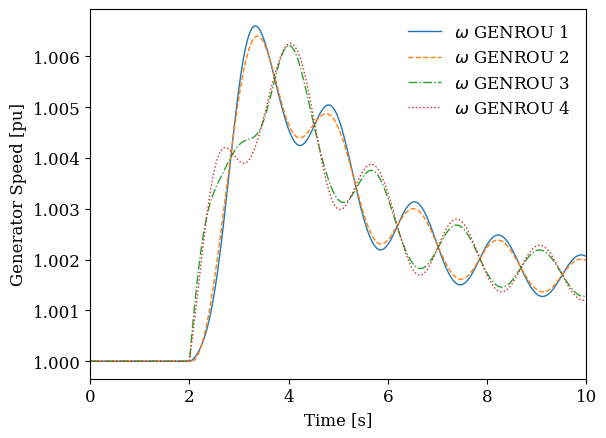

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time [s]', ylabel='Generator Speed [pu]'>)

In [17]:
# Plot generator rotor speeds showing inter-area oscillations
ss_tds.TDS.plt.plot(ss_tds.GENROU.omega, ylabel='Generator Speed [pu]')

### Adding a Fault Programmatically

Disturbances can be added through the Python API before setup.
This is the mechanism used for batch data generation: each scenario
is constructed programmatically with different fault locations,
clearing times, or load levels.

In [18]:
ss_fault = andes.load(andes.get_case('kundur/kundur_full.xlsx'), setup=False)

# Disable the existing Toggle event
ss_fault.Toggle.set('u', 1, 0)

# Add a three-phase fault on bus 5: apply at t=1.0s, clear at t=1.1s
ss_fault.add('Fault', bus=5, tf=1.0, tc=1.1)

ss_fault.setup()
ss_fault.PFlow.run()
ss_fault.TDS.config.tf = 5
ss_fault.TDS.run()

Working directory: "/home/hcui9/repos/gridfm-tutorial"
> Loaded config from file "/home/hcui9/.andes/andes.rc"
> Reloaded generated Python code of module "pycode".
Parsing input file "/home/hcui9/repos/andes/andes/cases/kundur/kundur_full.xlsx"...
Input file parsed in 0.0192 seconds.
Connectivity check completed in 0.0000 seconds.
-> System connectivity check results:
  No islanded bus detected.
  System is interconnected.
  Each island has a slack bus correctly defined and enabled.
System internal structure set up in 0.0116 seconds.

-> Power flow calculation
           Numba: On
   Sparse solver: KLU
 Solution method: NR method
Numba compilation initiated with caching.
Power flow initialized in 0.0029 seconds.
Numba compilation for power flow finished in 0.0236 seconds.
0: |F(x)| = 14.9282832
1: |F(x)| = 3.608627841
2: |F(x)| = 0.1701107882
3: |F(x)| = 0.002038626956
4: |F(x)| = 3.745104015e-07
Converged in 5 iterations in 0.0011 seconds.
Report saved to "kundur_full_out.txt" in 0.00

  0%|          | 0/100 [00:00<?, ?%/s]

<Fault Fault_2>: Applying fault on Bus (idx=5) at t=1.0 sec.
<Fault Fault_2>: Clearing fault on Bus (idx=5) at t=1.1 sec.
Simulation to t=5.00 sec completed in 0.1673 seconds.
Outputs to "kundur_full_out.lst" and "kundur_full_out.npz".
Outputs written in 0.0046 seconds.


True

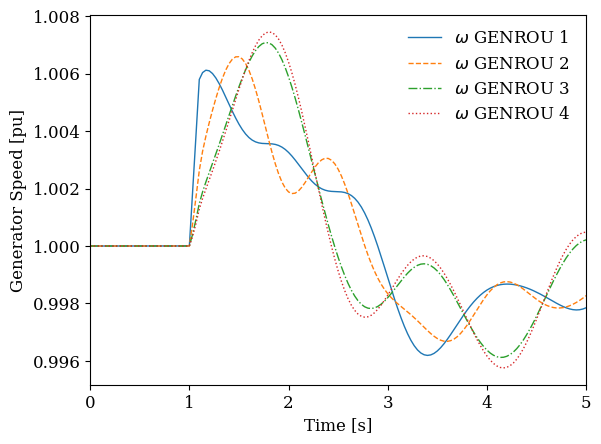

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time [s]', ylabel='Generator Speed [pu]'>)

In [19]:
ss_fault.TDS.plt.plot(ss_fault.GENROU.omega, ylabel='Generator Speed [pu]')

### Extracting Time Series as DataFrames

The `get_timeseries()` method returns results as a pandas DataFrame,
directly compatible with ML data pipelines.

In [20]:
omega_df = ss_fault.TDS.get_timeseries(ss_fault.GENROU.omega)
print(f"Shape: {omega_df.shape}")
print(f"Columns (generator indices): {list(omega_df.columns)}")
omega_df.head()

Shape: (158, 4)
Columns (generator indices): [1, 2, 3, 4]


,1,2,3,4
0.000000,1.0,1.0,1.0,1.0
0.033333,1.0,1.0,1.0,1.0
0.066667,1.0,1.0,1.0,1.0
0.100000,1.0,1.0,1.0,1.0
0.133333,1.0,1.0,1.0,1.0


## Inspecting Models Symbolically

This is where ANDES diverges from conventional simulators.
The symbolic equations that define each model are accessible at runtime.
These are the same expressions that a foundation model would learn to approximate.

The GENROU (round-rotor synchronous generator) model is examined below.
Its differential equations govern rotor dynamics, flux linkages, and
excitation, while the algebraic equations enforce the stator circuit
and network interface.

In [21]:
# List all state variables and their equation strings
print("GENROU State Variables (Differential Equations)")
print("=" * 60)
for name, var in ss_tds.GENROU.cache.states_and_ext.items():
    if var.e_str:
        tc = getattr(var, 't_const', None)
        tc_str = f" / {tc.name}" if tc else ""
        print(f"  d({name})/dt{tc_str} = {var.e_str}")
        print(f"    info: {var.info}")
        print()

GENROU State Variables (Differential Equations)
  d(delta)/dt = ue * (2 * pi * fn) * (omega - 1)
    info: rotor angle

  d(omega)/dt / M = ue * (tm - te - D * (omega - 1))
    info: rotor speed

  d(e1q)/dt / Td10 = (-XadIfd + vf)
    info: q-axis transient voltage

  d(e1d)/dt / Tq10 = -XaqI1q
    info: d-axis transient voltage

  d(e2d)/dt / Td20 = (-e2d + e1q - (xd1 - xl) * Id)
    info: d-axis sub-transient voltage

  d(e2q)/dt / Tq20 = (-e2q + e1d + (xq1 - xl) * Iq)
    info: q-axis sub-transient voltage



In [22]:
# List algebraic equations
print("GENROU Algebraic Equations")
print("=" * 60)
for name, var in ss_tds.GENROU.cache.algebs_and_ext.items():
    if var.e_str:
        print(f"  0 = {var.e_str}")
        print(f"    variable: {name} ({var.info})")
        print()

GENROU Algebraic Equations
  0 = + psid+ xd2*Id - psi2d
    variable: Id (d-axis current)

  0 = + psiq+ xq2*Iq + psi2q
    variable: Iq (q-axis current)

  0 = ue * v * sin(delta - a) - vd
    variable: vd (d-axis voltage)

  0 = ue * v * cos(delta - a) - vq
    variable: vq (q-axis voltage)

  0 = tm0 - tm
    variable: tm (mechanical torque)

  0 = ue * (psid * Iq - psiq * Id) - te
    variable: te (electric torque)

  0 = ue * vf0 - vf
    variable: vf (excitation voltage)

  0 = ue * (e1q + (xd-xd1) * (gd1*Id - gd2*e2d + gd2*e1q) + Se*psi2d) - XadIfd
    variable: XadIfd (d-axis armature excitation current)

  0 = ue * (vd * Id + vq * Iq) - Pe
    variable: Pe (active power injection)

  0 = ue * (vq * Id - vd * Iq) - Qe
    variable: Qe (reactive power injection)

  0 = ue * (ra*Iq + vq) - psid
    variable: psid (d-axis flux)

  0 = ue * (ra*Id + vd) + psiq
    variable: psiq (q-axis flux)

  0 = gq1*e1d + (1-gq1)*e2q - psi2q
    variable: psi2q (q-axis air gap flux)

  0 = gd1*

### Symbolic Jacobian Structure

ANDES derives Jacobian matrices symbolically from these equations.
The sparsity pattern reflects the physical coupling between variables.
For foundation model research, this structure encodes the graph topology
of the power system.

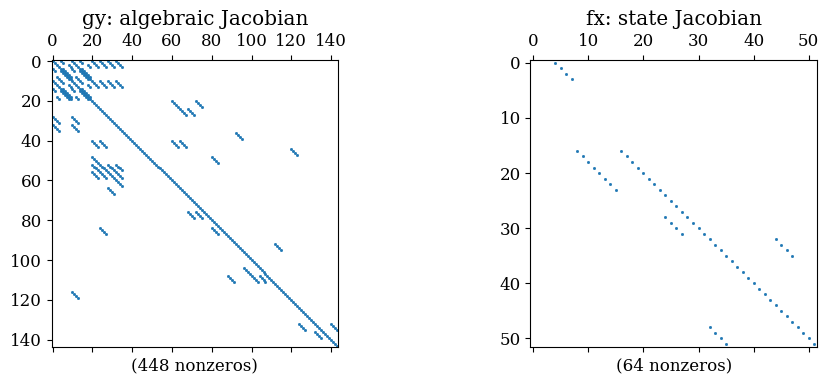

In [ ]:
from matplotlib import pyplot as plt
from andes.linsolvers.scipy import spmatrix_to_csc

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# convert from kvxopt.spmatrix to scipy.sparse.csc_matrix
fx = spmatrix_to_csc(ss_tds.dae.fx)
gy = spmatrix_to_csc(ss_tds.dae.gy)

# Jacobian sparsity patterns
axes[0].spy(gy, markersize=1)
axes[0].set_title('gy: algebraic Jacobian')
axes[0].set_xlabel(f'({gy.nnz} nonzeros)')

axes[1].spy(fx, markersize=1)
axes[1].set_title('fx: state Jacobian')
axes[1].set_xlabel(f'({fx.nnz} nonzeros)')

plt.tight_layout()
plt.show()

## Key Takeaway

ANDES provides a unified symbolic DAE framework where:

- **Power flow** solves the algebraic subset (g(y) = 0)
- **Time-domain simulation** integrates the full system (dx/dt = f(x,y), 0 = g(x,y))
- **Equations are accessible** as symbolic expressions, not hidden in compiled code

This transparency is what enables the ML integrations demonstrated in the
subsequent notebooks.

In [ ]:
!andes misc -C